# 05 — ED Utilization Patterns

## Objective

Identify temporal and encounter-level patterns associated with emergency department utilization, with emphasis on repeated and high-frequency use.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

DATA_PATH = Path("../data/raw")

encounters = pd.read_csv(DATA_PATH / "encounters.csv")
patients = pd.read_csv(DATA_PATH / "patients.csv")

encounters["START"] = pd.to_datetime(
    encounters["START"],
    errors="coerce",
    utc=True
)

encounters["STOP"] = pd.to_datetime(
    encounters["STOP"],
    errors="coerce",
    utc=True
)

ed = (
    encounters[
        encounters["ENCOUNTERCLASS"]
        .astype(str)
        .str.lower()
        .eq("emergency")
    ]
    .copy()
    .sort_values(["PATIENT", "START"])
)

print("ED PATTERN DATA")
print("-" * 50)
print(f"ED encounters: {len(ed):,}")
print(f"Unique ED patients: {ed['PATIENT'].nunique():,}")
print(f"Missing START dates: {ed['START'].isna().sum():,}")

ED PATTERN DATA
--------------------------------------------------
ED encounters: 270
Unique ED patients: 83
Missing START dates: 0


In [2]:
# Calculate time between consecutive ED encounters

ed["days_since_previous_ed"] = (
    ed.groupby("PATIENT")["START"]
      .diff()
      .dt.total_seconds()
      .div(86400)
)

repeat_visits = ed.dropna(subset=["days_since_previous_ed"]).copy()

print("TIME BETWEEN ED VISITS")
print("-" * 50)

print(f"Repeat ED encounters: {len(repeat_visits):,}")

print("\nDays between consecutive ED encounters:")
print(
    repeat_visits["days_since_previous_ed"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90])
    .round(1)
)

print("\nShort-interval revisits:")
for days in [7, 30, 90]:
    n = (repeat_visits["days_since_previous_ed"] <= days).sum()
    pct = n / len(repeat_visits) * 100
    print(f"Within {days:>2} days: {n:>3} ({pct:.1f}%)")

TIME BETWEEN ED VISITS
--------------------------------------------------
Repeat ED encounters: 187

Days between consecutive ED encounters:
count     187.0
mean      824.1
std      1440.0
min         3.0
25%         7.0
50%       191.0
75%      1043.0
90%      1998.2
max      8849.0
Name: days_since_previous_ed, dtype: float64

Short-interval revisits:
Within  7 days:  63 (33.7%)
Within 30 days:  80 (42.8%)
Within 90 days:  85 (45.5%)


In [3]:
# Classify patients by peak ED utilization within 365 days

def classify_utilization(peak):
    if peak == 1:
        return "Single-use"
    elif peak <= 2:
        return "Low"
    elif peak <= 5:
        return "Moderate"
    else:
        return "Frequent"

# Calculate peak ED encounters within 365 days for each patient
def peak_365(group):
    dates = group["START"].sort_values().reset_index(drop=True)
    peak = 1

    for i in range(len(dates)):
        count = ((dates >= dates[i]) &
                 (dates <= dates[i] + pd.Timedelta(days=365))).sum()
        peak = max(peak, count)

    return peak

patient_peak = (
    ed.groupby("PATIENT")
      .apply(peak_365)
      .rename("peak_ed_365d")
      .reset_index()
)

patient_peak["utilization_segment"] = (
    patient_peak["peak_ed_365d"].apply(classify_utilization)
)

repeat_visits = repeat_visits.merge(
    patient_peak[["PATIENT", "utilization_segment"]],
    on="PATIENT",
    how="left"
)

short_revisit_summary = (
    repeat_visits
    .groupby("utilization_segment", observed=True)
    .agg(
        repeat_visits=("PATIENT", "size"),
        median_days_between=("days_since_previous_ed", "median"),
        revisits_within_7d=("days_since_previous_ed", lambda x: (x <= 7).sum()),
        revisits_within_30d=("days_since_previous_ed", lambda x: (x <= 30).sum())
    )
)

short_revisit_summary["pct_within_7d"] = (
    short_revisit_summary["revisits_within_7d"] /
    short_revisit_summary["repeat_visits"] * 100
)

short_revisit_summary["pct_within_30d"] = (
    short_revisit_summary["revisits_within_30d"] /
    short_revisit_summary["repeat_visits"] * 100
)

print("SHORT-INTERVAL ED REVISITS BY UTILIZATION SEGMENT")
print("-" * 65)
print(short_revisit_summary.round(1))

SHORT-INTERVAL ED REVISITS BY UTILIZATION SEGMENT
-----------------------------------------------------------------
                     repeat_visits  median_days_between  revisits_within_7d  revisits_within_30d  pct_within_7d  pct_within_30d
utilization_segment                                                                                                            
Frequent                        85                  7.0                  59                   74           69.4            87.1
Low                             56                608.0                   2                    4            3.6             7.1
Moderate                        12                207.2                   2                    2           16.7            16.7
Single-use                      34               1388.0                   0                    0            0.0             0.0


C:\Users\Denisse Pareja\AppData\Local\Temp\ipykernel_19072\18678434.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(peak_365)


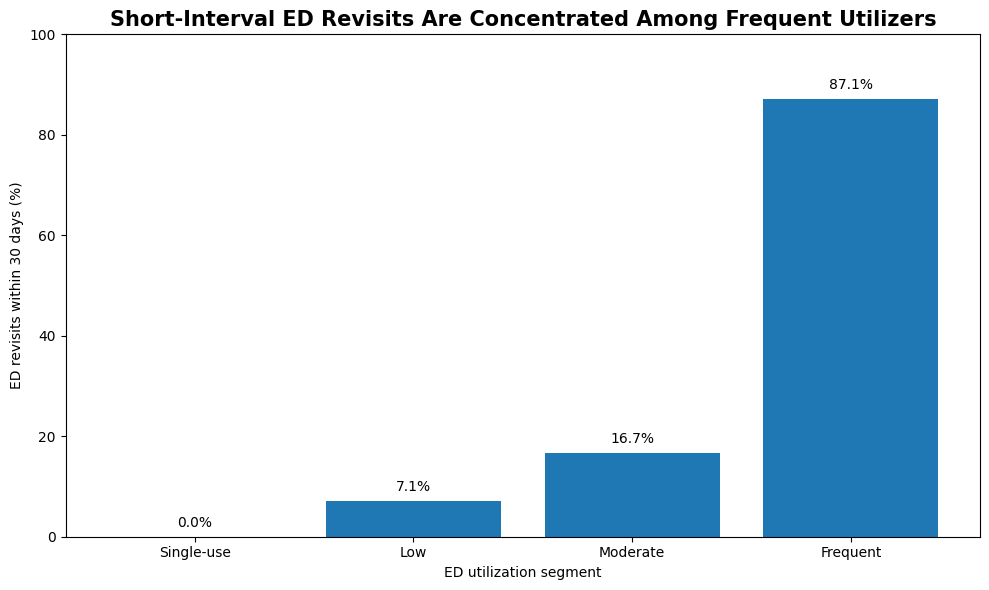

In [4]:
# Final figure — short-interval ED revisits

plot_df = (
    short_revisit_summary
    .reindex(["Single-use", "Low", "Moderate", "Frequent"])
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    plot_df.index,
    plot_df["pct_within_30d"]
)

ax.set_title(
    "Short-Interval ED Revisits Are Concentrated Among Frequent Utilizers",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel("ED revisits within 30 days (%)")
ax.set_xlabel("ED utilization segment")
ax.set_ylim(0, 100)

for bar, value in zip(bars, plot_df["pct_within_30d"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()

OUTPUT_PATH = Path("../reports/figures")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

plt.savefig(
    OUTPUT_PATH / "short_interval_ed_revisits.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Takeaways

- ED utilization was highly concentrated among a small subset of patients.
- Short-interval revisits were strongly concentrated among frequent ED utilizers: **87.1% of their repeat encounters occurred within 30 days**, compared with **7.1% among low utilizers** and **16.7% among moderate utilizers**.
- Frequent utilizers had a median interval of only **7 days between consecutive ED encounters**, suggesting clustered episodes of acute healthcare utilization rather than evenly distributed use over time.
- These findings complement the patient-level analysis showing that higher clinical burden was associated with greater ED utilization.

### Interpretation

The results suggest that identifying patients with repeated, closely spaced ED encounters may provide an actionable opportunity for targeted care coordination, follow-up, and outpatient support.

### Limitation

The frequent-utilizer group contained only **3 patients**, so these findings should be interpreted as exploratory patterns within this dataset rather than population-level estimates.